In [1]:
import pandas as pd
import regex as re
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import ast
import warnings
warnings.filterwarnings('ignore')

In [2]:
import ast
def readDataframe(csv_file):
    df = pd.read_csv(csv_file)
    try:
        df.drop(columns=['Unnamed: 0'],inplace=True)
    except:
        pass

    for column in df.columns:
        def safe_literal_eval(x):
            if isinstance(x, str) and pd.notna(x):
                try:    
                    return ast.literal_eval(x) if pd.notna(x) else x
                except (ValueError, SyntaxError):
                    return x  # Return empty list for problematic entries
            return x  # Return empty list for None or non-string entries
        df[column] = df[column].apply(safe_literal_eval)
    return df

In [3]:
def check_structure(df,config):
    df_exploded = df.explode('config_set_info').dropna(subset=['config_set_info'])
    df_exploded[['extracted_config_name', 'config_json']] = pd.DataFrame(df_exploded['config_set_info'].tolist(), index=df_exploded.index)
    df_filtered = df_exploded[df_exploded['extracted_config_name'] == config]
    df_filtered['timestamp'] = pd.to_datetime(df_filtered['timestamp'], errors='coerce')
    return df_filtered


def extract_config(config_list, target_config):
    for config_name, config_details in config_list:
        if config_name == target_config:
            return config_name, config_details
    return None, None  # Return None if the config is not found


def check_structure_fbq(df,target_config):
    
    df['fbq_config_name'], df['fbq_set_list'] = zip(*df['fbq_set_info'].apply(lambda x: extract_config(x, target_config)))
    return df


def get_config_filtered(df, config):
    df_exploded = df.explode('config_set_info').dropna(subset=['config_set_info'])

    # Split each tuple in 'config_set_info' into separate columns for config name and JSON setup
    df_exploded[['extracted_config_name', 'config_json']] = pd.DataFrame(df_exploded['config_set_info'].tolist(), index=df_exploded.index)

    # Filter for the 'automaticmatching' configuration
   
    
    df_filtered = df_exploded[df_exploded['extracted_config_name'] == config]

    df_filtered = df_filtered.dropna(subset=['timestamp'])

    return df_filtered

def get_fbq_set_filtered(df, config):
    df_exploded = df.explode('fbq_set_info').dropna(subset=['fbq_set_info'])

    # Split each tuple in 'config_set_info' into separate columns for config name and JSON setup
    df_exploded[['extracted_fbq_config_name', 'fbq_set_list']] = pd.DataFrame(df_exploded['fbq_set_info'].tolist(), index=df_exploded.index)

    # Filter for the 'automaticmatching' configuration
    df_filtered = df_exploded[df_exploded['extracted_fbq_config_name'] == config]

    df_filtered = df_filtered.dropna(subset=['timestamp'])

    return df_filtered

import json
from anytree import Node, RenderTree, PreOrderIter

def build_tree(data, parent=None):
    """Recursively build a tree structure from JSON keys."""
    if isinstance(data, dict):
        for key, value in data.items():
            # Create a new node with the current key and value
            node = Node(key, parent=parent, value=value)
            # Recursively build children nodes
            build_tree(value, node)
    elif isinstance(data, list):
        for index, item in enumerate(data):
            # Use the index as the node name for list items
            node = Node(f'[{index}]', parent=parent)
            # Recursively build children nodes
            build_tree(item, node)

def find_values(root,subconfig):
    """Find all nodes of a given type and return their values."""
    node_values = []
    for node in PreOrderIter(root):
        if node.name == subconfig and hasattr(node, 'value'):
            # Collect the value of the current "URL" node
            node_values.append(node.value)
    return node_values

# Takes in a json object, returns all values of that object

def find_subconfig(data,subconfig):
    if isinstance(data, str):
        data = json.loads(data)
    root = Node("root")
    build_tree(data, root)
    all_values = find_values(root,subconfig)
    return all_values

#takes in a dataframe, returns a list of all subconfigs of that type
def get_all_given_subconfigs(df,config,subconfig, fbq=False):
    df['month'] = df['timestamp'].dt.to_period('M')

    if not fbq:
        filtered = get_config_filtered(df, config)
        all_values = list(zip(
            filtered['website'],  # Assuming 'website' is the column for website identifier
            filtered['month'],
            filtered['config_json'].apply(lambda x: find_subconfig(x, subconfig))
        ))
    else:
            filtered = get_fbq_set_filtered(df, config)
            all_values = list(zip(
            filtered['website'],  # Assuming 'website' is the column for website identifier
            filtered['month'],
            filtered['config_json'].apply(lambda x: find_subconfig(x, subconfig))
        ))

    return all_values

In [4]:
# Specify paths to the processed configuration dataframe generated using processSnapshots.py
HOSPITAL_CONFIGURATION_DF_PATH = '../Configurations/health-configurations.csv' 
TOP_10K_CONFIGURATION_DF_PATH = '../Configurations/top-10k-configurations.csv'

hospital_websites = readDataframe(HOSPITAL_CONFIGURATION_DF_PATH)
top10k_websites = readDataframe(TOP_10K_CONFIGURATION_DF_PATH)

hospital_websites['timestamp'] = pd.to_datetime(hospital_websites['timestamp'])
top10k_websites['timestamp'] = pd.to_datetime(top10k_websites['timestamp'])

In [5]:
file_path = "hashes.txt"  
df = pd.read_csv(file_path, sep="\t", header=None, names=["Hash", "Type", "Result"], dtype=str)

def decryptedList(list):
    decrypted = []
    hash_found = []
    for i in list:
        if i in df['Hash'].values:
            text = df.loc[df['Hash'] == i]['Result'].values[0]
            if text == "Not found.":
                decrypted.append(i)
            else:
                decrypted.append(text)
                hash_found.append(text)
        else:
            decrypted.append(i)
    return decrypted,hash_found

In [6]:
def extract_sensitive_data(json_obj,key_type,data_type):
    sensitive_keys = json_obj.get(key_type, {})
    urls = []
    parent_keys = []
    
    if sensitive_keys:
        for key, value in sensitive_keys.items():
            if data_type in value:
                urls.extend(value[data_type])
                parent_keys.append(key)
    
    return urls, parent_keys

def gather_all_data(df, column_name, key_type,data_type):
    all_urls = []
    all_parent_keys = []
    
    for json_str in df[column_name]:
        
        try:
            urls, parent_keys = extract_sensitive_data(json_str, key_type,data_type)
            all_urls.extend(urls)
            all_parent_keys.extend(parent_keys)
        except json.JSONDecodeError:
            continue
    
    return all_urls, all_parent_keys

In [7]:
filtered_unwanteddata_hospitals = get_config_filtered(hospital_websites,"unwanteddata")
filtered_unwanteddata_top10k = get_config_filtered(top10k_websites,"unwanteddata")


hospital_sensitive_urls, hospital_sensitive_urls_parent_keys = gather_all_data(filtered_unwanteddata_hospitals, "config_json", "sensitive_keys","url")
hospital_sensitive_cds, hospital_sensitive_cds_parent_keys = gather_all_data(filtered_unwanteddata_hospitals, "config_json", "sensitive_keys","cd")
top10k_sensitive_urls, top10k_sensitive_urls_parent_keys = gather_all_data(filtered_unwanteddata_top10k, "config_json", "sensitive_keys","url")
top10k_sensitive_cds, top10k_sensitive_cds_parent_keys = gather_all_data(filtered_unwanteddata_top10k, "config_json", "sensitive_keys","cd")

all_sensitive_raw = hospital_sensitive_urls + top10k_sensitive_urls + hospital_sensitive_cds + top10k_sensitive_cds

In [8]:
filtered_unwanteddata_hospitals = get_config_filtered(hospital_websites,"unwanteddata")

hospital_sensitive_urls, hospital_sensitive_urls_parent_keys = gather_all_data(filtered_unwanteddata_hospitals, "config_json", "sensitive_keys","url")
hospital_sensitive_urls,hospital_hash_found_sensitive_urls = decryptedList(hospital_sensitive_urls)
hospital_sensitive_cds, hospital_sensitive_cds_parent_keys = gather_all_data(filtered_unwanteddata_hospitals, "config_json", "sensitive_keys","cd")
hospital_sensitive_cds, hospital_hash_found_sensitive_cd = decryptedList(hospital_sensitive_cds)

hospital_blacklisted_urls, hospital_blacklisted_urls_parent_keys = gather_all_data(filtered_unwanteddata_hospitals, "config_json", "blacklisted_keys","url")
hospital_blacklisted_cds, hospital_blacklisted_cds_parent_keys = gather_all_data(filtered_unwanteddata_hospitals, "config_json", "blacklisted_keys","cd")



filtered_unwanteddata_top10k = get_config_filtered(top10k_websites,"unwanteddata")

top10k_sensitive_urls, top10k_sensitive_urls_parent_keys = gather_all_data(filtered_unwanteddata_top10k, "config_json", "sensitive_keys","url")
top10k_sensitive_urls, top10k_hash_found_sensitive_url = decryptedList(top10k_sensitive_urls)
top10k_sensitive_cds, top10k_sensitive_cds_parent_keys = gather_all_data(filtered_unwanteddata_top10k, "config_json", "sensitive_keys","cd")
top10k_sensitive_cds, top10k_hash_found_sensitive_cd = decryptedList(top10k_sensitive_cds)

top10k_blacklisted_urls, top10k_blacklisted_urls_parent_keys = gather_all_data(filtered_unwanteddata_top10k, "config_json", "blacklisted_keys","url")
top10k_blacklisted_cds, top10k_blacklisted_cds_parent_keys = gather_all_data(filtered_unwanteddata_top10k, "config_json", "blacklisted_keys","cd")

In [9]:
all_sensitive_parent_keys = hospital_sensitive_urls_parent_keys + top10k_sensitive_urls_parent_keys + hospital_sensitive_cds_parent_keys + top10k_sensitive_cds_parent_keys
all_blacklisted_parent_keys = hospital_blacklisted_urls_parent_keys + top10k_blacklisted_urls_parent_keys + hospital_blacklisted_cds_parent_keys + top10k_blacklisted_cds_parent_keys

In [10]:
all_hospital_sensitive = hospital_hash_found_sensitive_urls + hospital_hash_found_sensitive_cd
all_hospital_blacklisted = hospital_blacklisted_urls + hospital_blacklisted_cds

all_top10k_sensitive = top10k_hash_found_sensitive_url + top10k_hash_found_sensitive_cd
all_top10k_blacklisted = top10k_blacklisted_urls + top10k_blacklisted_cds

all_sensitive = all_hospital_sensitive + all_top10k_sensitive
all_blacklisted = all_hospital_blacklisted + all_top10k_blacklisted

In [11]:
len(set(all_blacklisted))

4651

## Finding percentages of websites with given keys

In [12]:
def extract_sensitive_data(json_obj,key_type):
    sensitive_keys = json_obj.get(key_type, {})
    urls = []
    parent_keys = []
    
    if sensitive_keys:
        print(sensitive_keys)
        for key, value in sensitive_keys.items():
            if "cd" in value:
                urls.extend(value["cd"])
                parent_keys.append(key)
            if "url" in value:
                urls.extend(value["url"])
                parent_keys.append(key)
            
    
    return urls

### Get category counts

**We removed categorical analysis of keys from our paper owing to space constraints. Nevertheless, we still use a dummy category ('Present') for keeping the analysis consistent.**

In [30]:
categories = pd.read_csv('key_categorizations.csv')
categories['category'] = categories['category'].apply(lambda x: 'Present')
categories

,key,category,justification
0,mdl,Present,"** The key ""mdl"" is ambiguous and does not pro..."
1,rurl,Present,"** The key ""rurl"" likely refers to a ""referrer..."
2,MIDD,Present,"** The key ""MIDD"" does not clearly fit into an..."
3,e,Present,"** The key ""e"" is too ambiguous and lacks cont..."
4,values,Present,"** The key ""values"" is ambiguous without addit..."
...,...,...,...
6774,https://web.archive.org/web/20240530200604/htt...,Present,"** The key ""account_id"" likely represents a un..."
6775,%3Ffirstname,Present,"** The key ""firstname"" relates to an individua..."
6776,rand,Present,"** The key ""rand"" does not clearly fit into an..."
6777,submitted%5Bfirst_name%5D,Present,"** The key ""submitted[first_name]"" indicates d..."


In [13]:
import pandas as pd
from collections import defaultdict


def sensitive_category_counts(df):

    hash_reversed = pd.read_csv('/home/abdullah/dump/Documents/LUMSU/Other/drp2.0/Tracking-Project/Scripts/ConfigAnalysis/hashes_found.csv')

    filtered_unwanteddata = get_config_filtered(df,"unwanteddata")

    def extract_sensitive_data(json_obj, key_type):
        sensitive_keys = json_obj.get(key_type, {})
        keys = []
        
        if sensitive_keys:
            for key, value in sensitive_keys.items():
                if "cd" in value:
                    keys.extend(value["cd"])
                if "url" in value:
                    keys.extend(value["url"])            
        return keys

    # Step 1: Extract sensitive keys for each record
    filtered_unwanteddata['sensitive_keys'] = filtered_unwanteddata['config_json'].apply(
        lambda x: extract_sensitive_data(x, 'sensitive_keys')
    )

    # Step 2: Aggregate unique keys per website
    website_unique_keys = filtered_unwanteddata.groupby('website')['sensitive_keys'].agg(
        lambda x: set(k for keys_list in x for k in keys_list)
    ).reset_index()

    # Decryption step
    # if not hash_reversed.empty:
    #     hash_to_decrypted = dict(zip(hash_reversed['Hash'], hash_reversed['Result']))
    #     def decrypt_keys(hashed_keys):
    #         check =  {hash_to_decrypted.get(k, k) for k in hashed_keys}
    #         return check
    #     # Create new column with decrypted keys
    #     website_unique_keys['decrypted_keys'] = website_unique_keys['sensitive_keys'].apply(decrypt_keys)
    # else:
    #     # If no decryption mapping available, use original keys
    #     website_unique_keys['decrypted_keys'] = website_unique_keys['sensitive_keys']

    # Step 3: Create mapping from key to category
    key_to_category = dict(zip(categories['key'], categories['category']))

    # # Step 4: Map keys to categories for each website
    # website_categories = []
    # for _, row in website_unique_keys.iterrows():
    #     website = row['website']
    #     keys = row['decrypted_keys']  # Use decrypted keys here
    #     categories_list = set()
    #     for key in keys:
    #         if key in key_to_category:
    #             categories_list.add(key_to_category[key])  # Fixed parentheses issue
    #     website_categories.append({'website': website, 'categories': list(categories_list)})

    website_categories = []
    for _, row in website_unique_keys.iterrows():
        website = row['website']
        keys = row['sensitive_keys']
        categories_list = set()
        for key in keys:
            if key in all_sensitive_raw:
                categories_list.add('Present')
        website_categories.append({'website': website, 'categories': list(categories_list)})

    website_categories_df = pd.DataFrame(website_categories)

    # Step 5: Explode categories and count unique websites per category
    exploded_df = website_categories_df.explode('categories')
    category_counts = exploded_df.groupby('categories')['website'].nunique().to_dict()

    return category_counts


def blacklisted_category_counts(df):

    filtered_unwanteddata = get_config_filtered(df,"unwanteddata")
    hash_reversed = pd.read_csv('/home/abdullah/dump/Documents/LUMSU/Other/drp2.0/Tracking-Project/Scripts/ConfigAnalysis/hashes_found.csv')

    def extract_sensitive_data(json_obj,key_type):
        sensitive_keys = json_obj.get(key_type, {})
        urls = []
        
        if sensitive_keys:
            for key, value in sensitive_keys.items():
                if "cd" in value:
                    urls.extend(value["cd"])
                if "url" in value:
                    urls.extend(value["url"])            
        return urls

    # Step 1: Extract parent keys for each record
    filtered_unwanteddata['blacklisted_keys'] = filtered_unwanteddata['config_json'].apply(lambda x: extract_sensitive_data(x, 'blacklisted_keys'))

    # Step 2: Aggregate unique keys per website
    website_unique_keys = filtered_unwanteddata.groupby('website')['blacklisted_keys'].agg(
        lambda x: set(k for keys_list in x for k in keys_list)
    ).reset_index()


    # Step 3: Create a mapping from key to category
    key_to_category = dict(zip(categories['key'], categories['category']))

    # Step 4: Map keys to categories for each website
    website_categories = []
    for _, row in website_unique_keys.iterrows():
        website = row['website']
        keys = row['blacklisted_keys']
        categories_list = set()
        for key in keys:
            if key in all_blacklisted:
                categories_list.add('Present')
        website_categories.append({'website': website, 'categories': list(categories_list)})

    website_categories_df = pd.DataFrame(website_categories)

    # Step 5: Explode categories and count unique websites per category
    exploded_df = website_categories_df.explode('categories')
    category_counts = exploded_df.groupby('categories')['website'].nunique().to_dict()

    return category_counts

In [14]:
def extract_sensitive_data(json_obj, key_type):
    sensitive_keys = json_obj.get(key_type, {})
    keys = []
    
    if sensitive_keys:
        for key, value in sensitive_keys.items():
            if "cd" in value:
                keys.extend(value["cd"])
            if "url" in value:
                keys.extend(value["url"])            
    return keys


In [15]:
def extract_sensitive_data_events(json_obj):

    blacklisted_keys = json_obj.get("blacklisted_keys", {})
    sensitive_keys = json_obj.get('sensitive_keys', {})
    urls = []
    parent_keys = []
    
    if sensitive_keys:
        for key, value in sensitive_keys.items():
            parent_keys.append(key)
    if blacklisted_keys:
        for key, value in blacklisted_keys.items():
            parent_keys.append(key)
    
    return parent_keys

In [17]:
egeregious = ['Request OB GYN Appointment','Maternity - Call Toll Free','Symptom - Touch reason','PTSD Quiz','OCD','Cedar Hills DUI_Click to Call','ImpressionGileadhiv','CardiovascularSurgery','ImpressionTevaMigraine','credit_card_form_loaded','Matchmaking Experts Survey Resumed','Matchmaking Experts Survey Resumed','RU Romance Novels','loan_confirmed','MortgageLeadSubmit','Low testosterone form submit','Anxiety Quiz','Bet Receipt','BespokeWeddingO2OEvent2','Bookmaker Login Success','Get Free Coupon - Drug Page']

In [16]:
filtered_unwanteddata_hospitals['sensitive_keys'] = filtered_unwanteddata_hospitals['config_json'].apply(
        lambda x: extract_sensitive_data(x, 'sensitive_keys')
    )

In [17]:
key_to_find = "dise"

# if key_to_find in all_blacklisted:
#     print("STOP")

hash_reversed = pd.read_csv('/home/abdullah/dump/Documents/LUMSU/Other/drp2.0/Tracking-Project/Scripts/ConfigAnalysis/hashes_found.csv')

def check_key(hash_list):
    if '48a53f0774c8ceff574a1fdcb0d470dbd382b3db273cff4344b6d39d5379c923' in hash_list:
        return True
    else:
        return False
    
def check_blacklisted_key(hash_list):
    if 'content' in hash_list:
        return True
    else:
        return False

def check_website(hash_list):
    for hash in hash_list:
        if hash in hash_reversed['Hash'].values and hash_reversed.loc[hash_reversed['Hash'] == hash]['Result'].values[0] == key_to_find:
            return True
        else:
            return False

def chec_hash_val(hash):
    if hash in hash_reversed['Hash'].values:
        # text = hash_reversed.loc[hash_reversed['Hash'] == hash]['Result'].values[0]
        return True
    else:
        return False
    

    
filtered_unwanteddata = get_config_filtered(hospital_websites,"unwanteddata")
filtered_unwanteddata['sensitive_keys'] = filtered_unwanteddata['config_json'].apply(
        lambda x: extract_sensitive_data(x, 'sensitive_keys')
    )
filtered_unwanteddata['sensitive_key_events'] = filtered_unwanteddata['config_json'].apply(lambda x: extract_sensitive_data_events(x))
# filtered_unwanteddata['sensitive_keys_found'] = filtered_unwanteddata['sensitive_keys'].apply(lambda x: check_key(x))
# filtered_unwanteddata[filtered_unwanteddata['sensitive_keys_found'] == True]

# filtered_unwanteddata = get_config_filtered(hospital_websites,"unwanteddata")
# filtered_unwanteddata['sensitive_keys'] = filtered_unwanteddata['config_json'].apply(
#         lambda x: extract_sensitive_data(x, 'sensitive_keys')
#     )
# filtered_unwanteddata['blacklisted_keys'] = filtered_unwanteddata['config_json'].apply(
#         lambda x: extract_sensitive_data(x, 'blacklisted_keys')
#     )
# filtered_unwanteddata['blacklisted_keys_found'] = filtered_unwanteddata['blacklisted_keys'].apply(lambda x: check_blacklisted_key(x))
# filtered_unwanteddata[filtered_unwanteddata['blacklisted_keys_found'] == True]



In [18]:
exploded_events = filtered_unwanteddata.explode('sensitive_key_events')

In [19]:
exploded_events[exploded_events['sensitive_key_events']=='PTSD Quiz']

,plugin_name,opt_in_info,config_set_info,fbq_set_info,timestamp,website,pixel_id,year,extracted_config_name,config_json,sensitive_keys,sensitive_key_events
8035,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","(unwanteddata, {'blacklisted_keys': {'PageView...","[(iwlextractors, [])]",2021-02-20 13:05:04,rogersbh.org,142361239747630,2021,unwanteddata,"{'blacklisted_keys': {'PageView': {'cd': [], '...",[f284a6ede1e55f8f5e3867eba8c2a87b1d098390dfb54...,PTSD Quiz
8036,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","(unwanteddata, {'blacklisted_keys': {'PageView...","[(iwlextractors, [])]",2021-02-20 13:05:06,rogersbh.org,1803784436360159,2021,unwanteddata,"{'blacklisted_keys': {'PageView': {'cd': [], '...",[f284a6ede1e55f8f5e3867eba8c2a87b1d098390dfb54...,PTSD Quiz
8037,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","(unwanteddata, {'blacklisted_keys': {'PageView...","[(iwlextractors, [])]",2021-02-20 13:05:07,rogersbh.org,159832448007429,2021,unwanteddata,"{'blacklisted_keys': {'PageView': {'cd': [], '...",[8e35c2cd3bf6641bdb0e2050b76932cbb2e6034a0ddac...,PTSD Quiz
8038,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","(unwanteddata, {'blacklisted_keys': {'PageView...","[(iwlextractors, [])]",2021-02-20 13:05:08,rogersbh.org,491815041196424,2021,unwanteddata,"{'blacklisted_keys': {'PageView': {'cd': [], '...",[948fe603f61dc036b5c596dc09fe3ce3f3d30dc90f024...,PTSD Quiz


In [20]:
exploded_events[exploded_events['sensitive_key_events']=='OCD']

,plugin_name,opt_in_info,config_set_info,fbq_set_info,timestamp,website,pixel_id,year,extracted_config_name,config_json,sensitive_keys,sensitive_key_events
8035,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","(unwanteddata, {'blacklisted_keys': {'PageView...","[(iwlextractors, [])]",2021-02-20 13:05:04,rogersbh.org,142361239747630,2021,unwanteddata,"{'blacklisted_keys': {'PageView': {'cd': [], '...",[f284a6ede1e55f8f5e3867eba8c2a87b1d098390dfb54...,OCD
8036,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","(unwanteddata, {'blacklisted_keys': {'PageView...","[(iwlextractors, [])]",2021-02-20 13:05:06,rogersbh.org,1803784436360159,2021,unwanteddata,"{'blacklisted_keys': {'PageView': {'cd': [], '...",[f284a6ede1e55f8f5e3867eba8c2a87b1d098390dfb54...,OCD
8037,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","(unwanteddata, {'blacklisted_keys': {'PageView...","[(iwlextractors, [])]",2021-02-20 13:05:07,rogersbh.org,159832448007429,2021,unwanteddata,"{'blacklisted_keys': {'PageView': {'cd': [], '...",[8e35c2cd3bf6641bdb0e2050b76932cbb2e6034a0ddac...,OCD
8038,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","(unwanteddata, {'blacklisted_keys': {'PageView...","[(iwlextractors, [])]",2021-02-20 13:05:08,rogersbh.org,491815041196424,2021,unwanteddata,"{'blacklisted_keys': {'PageView': {'cd': [], '...",[948fe603f61dc036b5c596dc09fe3ce3f3d30dc90f024...,OCD


In [21]:
exploded_events[exploded_events['sensitive_key_events']=='Low Testosterone Form Submit']

,plugin_name,opt_in_info,config_set_info,fbq_set_info,timestamp,website,pixel_id,year,extracted_config_name,config_json,sensitive_keys,sensitive_key_events
8886,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","(unwanteddata, {'blacklisted_keys': {'PageView...","[(iwlextractors, [])]",2021-08-30 05:46:10,houstonmethodist.org,244102129294472,2021,unwanteddata,"{'blacklisted_keys': {'PageView': {'cd': [], '...",[872b449a658da8f888dab054165fb281f7183b07dab65...,Low Testosterone Form Submit


#### Necessary preliminary step

In [23]:
top10k_websites['year'] = top10k_websites['timestamp'].dt.year
hospital_websites['year'] = hospital_websites['timestamp'].dt.year
valid_years = [2020,2021,2022,2023,2024]
top10k_websites = top10k_websites[top10k_websites['year'].isin(valid_years)]
hospital_websites = hospital_websites[hospital_websites['year'].isin(valid_years)]

### Sensitive Percentage

In [31]:
def get_sensitive_yearly_category_proportions(main_df, categories_df):
    """Process dataframe to get yearly category proportions"""
    # Get all unique years sorted
    years = sorted(main_df['year'].unique())
    
    yearly_counts = {}
    
    for year in years:
        # Filter data for current year
        year_df = main_df[main_df['year'] == year]
        
        # Get raw category counts for this year
        counts = sensitive_category_counts(year_df)
        
        # Calculate percentage
        total = main_df['website'].nunique()
        proportions = {k: (v/total)*100 for k, v in counts.items()}
        
        yearly_counts[year] = proportions
    
    # Convert to dataframe
    all_categories = sorted(categories_df['category'].unique())
    data = {year: [yearly_counts[year].get(cat, 0) for cat in all_categories] 
            for year in yearly_counts}
    
    return pd.DataFrame(data, index=all_categories)

### Blacklisted Percentage

In [32]:
def get_blacklisted_yearly_category_proportions(main_df, categories_df):
    """Process dataframe to get yearly category proportions"""
    # Get all unique years sorted
    years = sorted(main_df['year'].unique())
    
    yearly_counts = {}
    
    for year in years:
        # Filter data for current year
        year_df = main_df[main_df['year'] == year]
        
        # Get raw category counts for this year
        counts = blacklisted_category_counts(year_df)
        
        # Calculate proportions
        total = main_df['website'].nunique()
        proportions = {k: (v/total)*100 for k, v in counts.items()}
        
        yearly_counts[year] = proportions
    
    # Convert to dataframe
    all_categories = sorted(categories_df['category'].unique())
    data = {year: [yearly_counts[year].get(cat, 0) for cat in all_categories] 
            for year in yearly_counts}
    
    return pd.DataFrame(data, index=all_categories)

### Heatmap function

In [33]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np
import pandas as pd


def plot_category_heatmaps(top10k_df, hospital_df, save_path=None):
    # Set global font settings
    font_path = '/home/abdullah/.local/share/fonts/SourceSans3-Regular.otf'
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Source Sans 3']
    sns.set_theme(style="white", context="talk")

    # Create figure with adjusted layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10), dpi=300)
    plt.subplots_adjust(bottom=0.22)  # Make space for colorbar

    # Shared parameters with colorbar disabled
    heatmap_kwargs = {
        'cmap': 'YlOrRd',
        'annot': True,
        'fmt': '.1f',
        'linewidths': 0.5,
        'linecolor': 'white',
        'square': True,
        'cbar': False,  # Disable individual colorbars
        'annot_kws': {'size': 20, 'color': 'black'},
        'vmin': 0,
        'vmax': 100
    }

    # Plot heatmaps
    sns.heatmap(top10k_df, ax=ax1, **heatmap_kwargs)
    sns.heatmap(hospital_df, ax=ax2, **heatmap_kwargs)

    # Add titles
    # Create unified horizontal colorbar
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.03])  # [left, bottom, width, height]
    norm = mpl.colors.Normalize(vmin=0, vmax=100)
    cb = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap='YlOrRd'),
        cax=cbar_ax,
        orientation='horizontal',
        format='%.0f%%'
    )
    cb.set_label('Percentage of Websites (%)', size=18, weight='medium', labelpad=10)
    cb.ax.tick_params(labelsize=20)

    # Axis labels and styling
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', labelsize=18)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Add frame
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#404040')
            spine.set_linewidth(0.5)

    ax2.set_ylabel('')

    # Final adjustments
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        
    plt.show()


# top10k_yearly = get_blacklisted_yearly_category_proportions(top10k_websites, categories)
# hospital_yearly = get_blacklisted_yearly_category_proportions(hospital_websites, categories)


# plot_category_heatmaps(
#     top10k_yearly.T,  # Transpose to match years as columns
#     hospital_yearly.T,
#     save_path='blacklist_heatmaps.png'
# )

In [38]:
hosp_sens = get_sensitive_yearly_category_proportions(hospital_websites, categories).T
hosp_sens

,Present
2020,0.000000
2021,25.788901
2022,21.762786
2023,7.508161
2024,4.243743


In [34]:
def get_sensitive_category_proportions(main_df, categories_df):
    """Process dataframe to get yearly category proportions"""
    # Get all unique years sorted
    years = sorted(main_df['year'].unique())    
    
        
        # Get raw category counts for this year
    counts = sensitive_category_counts(main_df)
    
    # Calculate percentage
    total = main_df['website'].nunique()
    proportions = {k: (v/total)*100 for k, v in counts.items()}
    
    # Convert to dataframe
    all_categories = sorted(categories_df['category'].unique())
    
    return pd.DataFrame(proportions, index=all_categories)

def get_blacklisted_category_proportions(main_df, categories_df):
    """Process dataframe to get yearly category proportions"""
    # Get all unique years sorted
 
        # Filter data for current year
        
        # Get raw category counts for this year
    counts = blacklisted_category_counts(main_df)
        
        # Calculate proportions
    total = main_df['website'].nunique()
    proportions = {k: (v/total)*100 for k, v in counts.items()}
            
    # Convert to dataframe
    all_categories = sorted(categories_df['category'].unique())

    
    return pd.DataFrame(proportions, index=all_categories)

In [28]:
def get_blacklisted_yearly_category_proportions(main_df, categories_df):
    """Process dataframe to get yearly category proportions"""
    # Get all unique years sorted
    years = sorted(main_df['year'].unique())
    
    yearly_counts = {}
    
    for year in years:
        # Filter data for current year
        year_df = main_df[main_df['year'] == year]
        
        # Get raw category counts for this year
        counts = blacklisted_category_counts(year_df)
        
        # Calculate proportions
        total = main_df['website'].nunique()
        proportions = {k: (v/total)*100 for k, v in counts.items()}
        
        yearly_counts[year] = proportions
    
    # Convert to dataframe
    all_categories = sorted(categories_df['category'].unique())
    data = {year: [yearly_counts[year].get(cat, 0) for cat in all_categories] 
            for year in yearly_counts}
    
    return pd.DataFrame(data, index=all_categories)

In [35]:
top_black = get_blacklisted_yearly_category_proportions(top10k_websites, categories).T
hosp_black = get_blacklisted_yearly_category_proportions(hospital_websites, categories).T
top_sens = get_sensitive_yearly_category_proportions(top10k_websites, categories).T
hosp_sens = get_sensitive_yearly_category_proportions(hospital_websites, categories).T

Averages

In [36]:
# avg_top_black = get_blacklisted_category_proportions(top10k_websites, categories).T
# avg_hosp_black = get_blacklisted_category_proportions(hospital_websites, categories).T
avg_top_sens = get_sensitive_category_proportions(top10k_websites, categories).T
avg_hosp_sens = get_sensitive_category_proportions(hospital_websites, categories).T

In [37]:
avg_top_sens

,Present
Present,11.217809


In [38]:
avg_hosp_sens

,Present
Present,35.799782


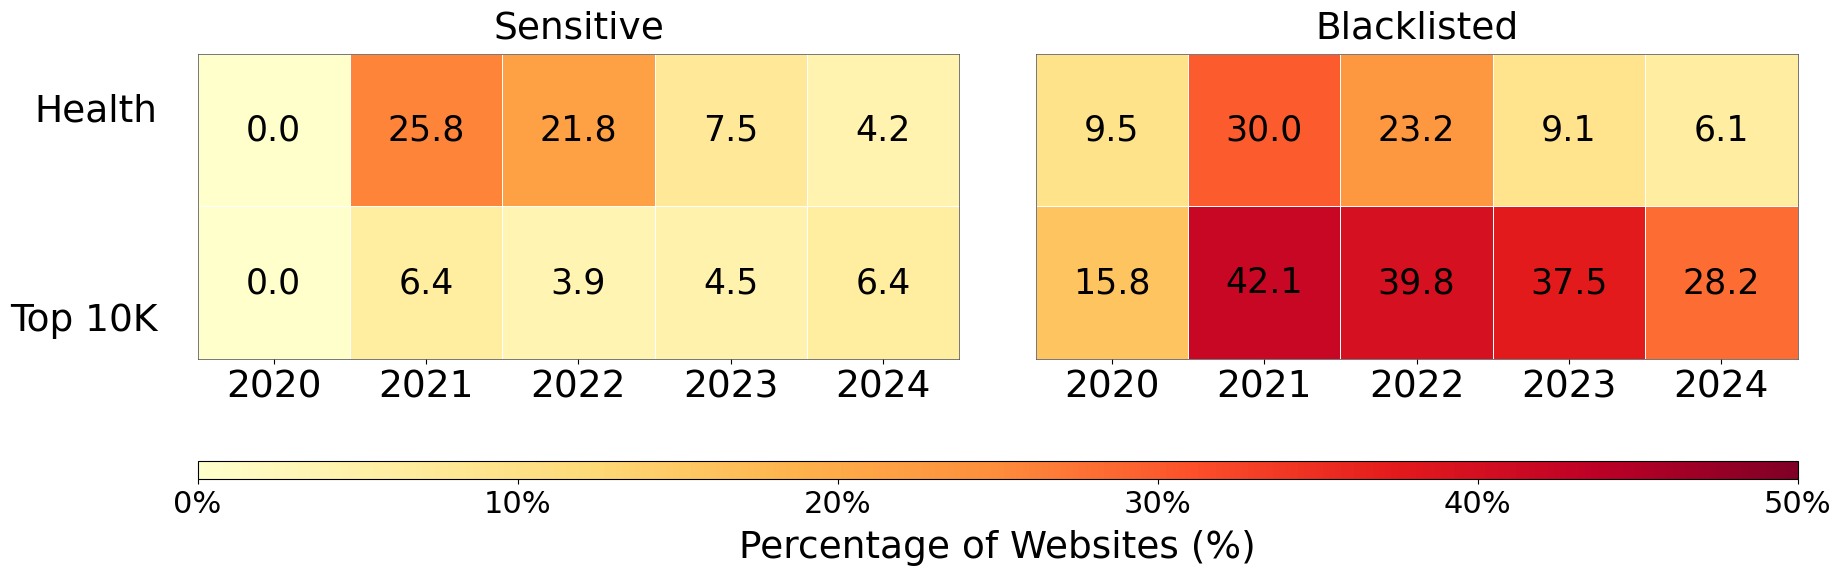

In [39]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd

def plot_dual_heatmap(blacklist_top, blacklist_hosp,
                      sensitive_top, sensitive_hosp,
                      save_path=None):
    # ---------- Build small DataFrames ----------
    sens = pd.concat({
        'Top10k': sensitive_top.iloc[:, 0],
        'Hospital': sensitive_hosp.iloc[:, 0]
    }, axis=1).T

    black = pd.concat({
        'Top10k': blacklist_top.iloc[:, 0],
        'Hospital': blacklist_hosp.iloc[:, 0]
    }, axis=1).T

    # ---------- Plot ----------
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(20, 6),
        sharey=True,
        gridspec_kw={'width_ratios': [1, 1]}
    )
    plt.subplots_adjust(left=0.15, right=0.95, bottom=0.15, wspace=0.1)

    heatmap_kwargs = dict(
        cmap='YlOrRd',
        annot=True,
        fmt='.1f',
        linewidths=0.5,
        linecolor='white',
        square=True,
        vmin=0,
        vmax=50,
        cbar=False,
        annot_kws={'size': 25, 'color': 'black'}
    )

    sns.heatmap(sens, ax=ax1, **heatmap_kwargs)
    sns.heatmap(black, ax=ax2, **heatmap_kwargs)

    # Titles
    ax2.set_title('Blacklisted', size=27, pad=12)
    ax1.set_title('Sensitive', size=27, pad=12)

    # Hide default y-ticks on both axes
    ax1.set_yticks([])
    ax2.set_yticks([])

    # X‐ticks
    ax1.set_xticklabels(sens.columns, rotation=0, ha='center', fontsize=27)
    ax2.set_xticklabels(black.columns, rotation=0, ha='center', fontsize=27)

    # Frame styling
    for ax in (ax1, ax2):
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#404040')
            spine.set_linewidth(0.5)

    # ---------- Shared row labels via figure.text ----------
    # We know the heatmaps sit roughly between fig‐coords y=0.15 and y=0.85
    # Two rows → cell‐height ≈ (0.85−0.15)/2 = 0.35
    # Row‐centers: 0.85−0.35/2=0.675 (Top10k) and 0.85−(0.35*1.5)=0.325 (Hospital)
    fig.text(0.13, 0.675, 'Health',  va='center', ha='right', fontsize=27)
    fig.text(0.13, 0.325, 'Top 10K',    va='center', ha='right', fontsize=27)

    # ---------- Shared colorbar at bottom ----------
    norm = mpl.colors.Normalize(vmin=0, vmax=50)
    cbar_ax = fig.add_axes([0.15, 0.06, 0.8, 0.03])  # [left, bottom, width, height]
    cb = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap='YlOrRd'),
        cax=cbar_ax,
        orientation='horizontal',
        format='%.0f%%'
    )
    cb.set_label('Percentage of Websites (%)', size=27, labelpad=8)
    cb.ax.tick_params(labelsize=22)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=600)
    plt.show()


# Example call:
plot_dual_heatmap(
    hosp_black,   # DataFrame for Hospital blacklisted
    top_black,    # DataFrame for Top10k blacklisted
    hosp_sens,     # DataFrame for Hospital sensitive
    top_sens,     # DataFrame for Top10k sensitive
    save_path='combined_unwanted_data.png'
)


### Blacklisted Difference (Appendix)

### Overlap of Sensitive Keys across websites

In [41]:
import pandas as pd
from collections import defaultdict





from tqdm import tqdm

def blacklisted_website_counts(df, all_blacklisted):
    key_counts = {key: 0 for key in all_blacklisted}

    # Step 1: Filter and extract blacklisted keys
    filtered_unwanteddata = get_config_filtered(df, "unwanteddata")

    def extract_sensitive_data(json_obj, key_type):
        sensitive_keys = json_obj.get(key_type, {})
        urls = []
        if sensitive_keys:
            for key, value in sensitive_keys.items():
                if "cd" in value:
                    urls.extend(value["cd"])
                if "url" in value:
                    urls.extend(value["url"])            
        return urls

    filtered_unwanteddata['blacklisted_keys'] = filtered_unwanteddata['config_json'].apply(
        lambda x: extract_sensitive_data(x, 'blacklisted_keys')
    )

    # Step 2: Aggregate unique keys per website
    website_unique_keys = filtered_unwanteddata.groupby('website')['blacklisted_keys'].agg(
        lambda x: set(k for keys_list in x for k in keys_list)
    ).reset_index()

    # Step 3: Count how many websites have each blacklisted key
    for key in tqdm(all_blacklisted, desc="Processing blacklisted keys"):
        for _, row in website_unique_keys.iterrows():
            if key in row['blacklisted_keys']:
                key_counts[key] += 1

    return key_counts


def sensitive_website_counts(df, all_sensitive):
    key_counts = {key: 0 for key in all_sensitive}

    # Step 1: Filter and extract blacklisted keys
    filtered_unwanteddata = get_config_filtered(df, "unwanteddata")

    def extract_sensitive_data(json_obj, key_type):
        sensitive_keys = json_obj.get(key_type, {})
        urls = []
        if sensitive_keys:
            for key, value in sensitive_keys.items():
                if "cd" in value:
                    urls.extend(value["cd"])
                if "url" in value:
                    urls.extend(value["url"])            
        return urls

    filtered_unwanteddata['sensitive_keys'] = filtered_unwanteddata['config_json'].apply(
        lambda x: extract_sensitive_data(x, 'sensitive_keys')
    )

    # Step 2: Aggregate unique keys per website
    website_unique_keys = filtered_unwanteddata.groupby('website')['sensitive_keys'].agg(
        lambda x: set(k for keys_list in x for k in keys_list)
    ).reset_index()

    # Step 3: Count how many websites have each blacklisted key
    for key in tqdm(all_sensitive, desc="Processing blacklisted keys"):
        for _, row in website_unique_keys.iterrows():
            if key in row['sensitive_keys']:
                key_counts[key] += 1

    return key_counts


In [42]:
sensitive_keys_website_counts = sensitive_website_counts(top10k_websites,set(all_sensitive_raw))

Processing blacklisted keys: 100%|██████████| 2406/2406 [04:45<00:00,  8.41it/s]


In [43]:
blacklisted_keys_website_counts = blacklisted_website_counts(top10k_websites,set(all_blacklisted))

Processing blacklisted keys: 100%|██████████| 4651/4651 [09:58<00:00,  7.77it/s]


In [44]:
sensitive_keys_hospital_website_counts = sensitive_website_counts(hospital_websites,set(all_sensitive_raw))
blacklisted_keys_hospital_website_counts = blacklisted_website_counts(hospital_websites,set(all_blacklisted))

Processing blacklisted keys: 100%|██████████| 4651/4651 [03:44<00:00, 20.68it/s]


In [45]:
from collections import Counter

combined_sensitive = dict(Counter(sensitive_keys_website_counts) + Counter(sensitive_keys_hospital_website_counts))
combined_blacklisted = dict(Counter(blacklisted_keys_website_counts) + Counter(blacklisted_keys_hospital_website_counts))


In [ ]:
target_keywords =   ['gender','client','height','query','search']

In [46]:
dict(sorted(combined_blacklisted.items(), key=lambda item: item[1],reverse=True))

{'lat': 1077,
 'password': 995,
 'lng': 744,
 'lastname': 672,
 'firstname': 656,
 'firstName': 655,
 'first_name': 597,
 'lastName': 596,
 'last_name': 577,
 'lon': 551,
 'schemaver': 491,
 'phone': 434,
 'dob': 379,
 'longitude': 371,
 'latitude': 363,
 'guestpassid': 355,
 'FirstName': 352,
 'LastName': 348,
 'address': 301,
 'q': 282,
 'payload': 276,
 'long': 230,
 'rtbdata2': 223,
 'em': 219,
 'cvid': 209,
 'client_ip': 209,
 'v': 204,
 'rtbip': 195,
 'mobile': 164,
 'ssn': 162,
 'real_ip': 148,
 'cid': 145,
 'user_ip': 142,
 'email': 126,
 'uaw': 126,
 'as_q': 122,
 'ip_addr': 114,
 'gdpr_consent': 107,
 'query': 104,
 'userIp': 95,
 'ip_address': 94,
 'oq': 82,
 'ipaddress': 82,
 'args': 82,
 'msclkid': 81,
 'streetaddress': 80,
 'refig': 79,
 'UIP': 75,
 'Password': 74,
 'mi_first_name': 73,
 'cv': 70,
 '["subscriber_data","lastname"]': 69,
 'location': 69,
 'xt_ver': 68,
 'e': 67,
 'password2': 65,
 'Phone': 64,
 'ip': 63,
 'birthdate': 63,
 'dobMonth': 61,
 'passcode': 60,
 

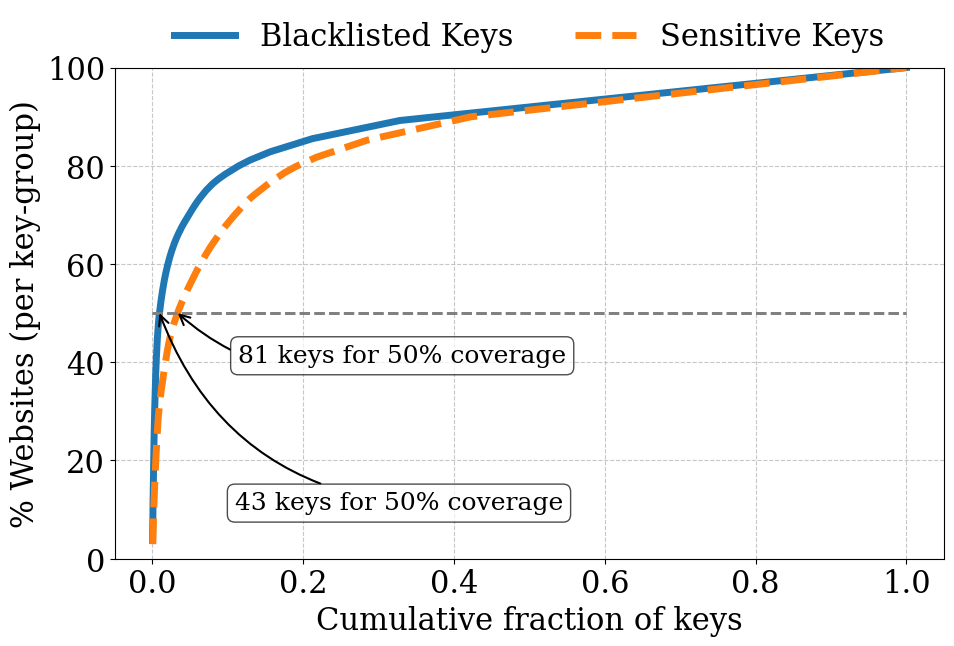

In [47]:

def plot_lorenz_with_threshold(dicts, labels, threshold_pct):
    # Publication‐style settings
    plt.rcParams['figure.figsize']  = (10, 7)
    plt.rcParams['font.family']     = 'serif'
    plt.rcParams['font.size']       = 22
    plt.rcParams['axes.labelsize']  = 22
    plt.rcParams['axes.titlesize']  = 22
    plt.rcParams['legend.fontsize'] = 22
    plt.rcParams['xtick.labelsize'] = 22
    plt.rcParams['ytick.labelsize'] = 22
    # plt.style.use('default')

    # Offsets for the two annotations

    offsets = [(0.10, 40), (0.08, 10)]

    fig, ax = plt.subplots()
    
    for idx, (data, label) in enumerate(zip(dicts, labels)):
        # Sort counts descending
        counts = np.array(sorted(data.values(), reverse=True))
        cum_keys  = np.arange(1, len(counts) + 1) / len(counts)
        cum_sites = np.cumsum(counts) / counts.sum() * 100

        style = '-' if idx == 0 else '--'
        ax.plot(cum_keys, cum_sites,
                label=label,
                linestyle=style,
                linewidth=5)

        # Find threshold crossing
        cross_idx = np.searchsorted(cum_sites, threshold_pct)
        key_frac  = cum_keys[cross_idx]
        n_keys    = cross_idx + 1

        # Choose a point halfway up the vertical line for the arrow tip
        vert_y = threshold_pct / 2

        # Draw horizontal & vertical guide lines
        ax.hlines(threshold_pct, 0, 1,
                  linestyles='--', linewidth=2, color='gray')
        # ax.vlines(key_frac, 0, threshold_pct,
        #           linestyles='--', linewidth=2, color='gray')

        # Annotate pointing at the vertical line
        dx, dy = offsets[idx]
        ax.annotate(
            f'{n_keys} keys for {threshold_pct}% coverage',
            xy=(key_frac, threshold_pct),                  # arrow tip (where curve crosses threshold)
            xytext=(key_frac + dx, threshold_pct - dy),    # text box below the tip
            textcoords='data',
            fontsize=18,
            arrowprops=dict(
                arrowstyle='->',
                lw=1.5,
                color='black',
                connectionstyle='arc3,rad=-0.3',           # arrow curves upward
                shrinkA=0,
                shrinkB=0
            ),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
        )
    # Finishing touches
    ax.set_xlabel('Cumulative fraction of keys')
    ax.set_ylabel('% Websites (per key‐group)')
    ax.set_ylim(0, 100)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save as PDF (before show)
    # plt.savefig("plot_unwanted_overlap.pdf",
    #             format="pdf",
    #             bbox_inches="tight",
    #             transparent=True)

    plt.show()

plot_lorenz_with_threshold(
    [combined_blacklisted, combined_sensitive],
    ['Blacklisted Keys', 'Sensitive Keys'],
    threshold_pct=50
)


In [274]:
dict(sorted(combined_blacklisted.items(), key=lambda item: item[1],reverse=True))

{'address': 614,
 'lat': 514,
 'lastname': 404,
 'longitude': 386,
 'latitude': 384,
 'password': 346,
 'firstname': 334,
 'em': 308,
 'lng': 302,
 'firstName': 296,
 'phone': 270,
 'last_name': 260,
 'cvid': 256,
 'first_name': 250,
 'as_q': 246,
 'guestpassid': 244,
 'dob': 206,
 'lastName': 196,
 'LastName': 184,
 'll': 180,
 'streetaddress': 154,
 'customer_password': 142,
 'FirstName': 130,
 'location': 130,
 'lon': 122,
 'crm_last_name': 104,
 'client_ip': 102,
 'crm_first_name': 94,
 'real_ip': 84,
 'payload': 78,
 'schemaver': 76,
 'long': 66,
 'searchTerm': 58,
 'msclkid': 58,
 'q': 56,
 'uaw': 50,
 'ssn': 48,
 'ipaddress': 42,
 'where1': 42,
 'oq': 42,
 'cid': 40,
 'email': 38,
 'FreeText:Last name': 38,
 '?q': 36,
 'e': 34,
 'crsi': 32,
 'Last_Name': 32,
 'First_Name': 32,
 'rtbdata2': 30,
 'refig': 30,
 'FreeText:First name': 28,
 'rtbip': 28,
 'display_location': 26,
 'searchFirstName': 26,
 'searchLastName': 26,
 'dobMonth': 26,
 'DOB': 24,
 'Phone': 24,
 'mobile': 24,
 '

In [318]:
only_sensitive = {}

for key, value in combined_sensitive_decrypted.items():
    if key not in overlap:
        only_sensitive[key] = value

dict(sorted(only_sensitive.items(), key=lambda item: item[1],reverse=True))

{'plvar': 694,
 '8f84b89bdc2aa18af73a15328a4761e8d8505100028f2224dd06cef0111c961b': 502,
 'height': 424,
 'scope': 400,
 'gender': 398,
 'form': 306,
 'f6c80f39edacded53548b613373490ed28b585223cb965a0a2a36a0edc55c7e2': 298,
 'start': 232,
 'staging': 196,
 'caps': 168,
 'specialty': 148,
 '19bd243537046c6643ae96ce6e34ef4bf2214f8e9e18fb943af0ff444cfe748b': 146,
 'taxonomy': 146,
 'qo': 144,
 'ocid': 144,
 'KW3': 128,
 'sort': 128,
 '5f00c738a53a74a9331ec4f41b87a9ff101d9d68ebdea6c7bbd489fde26527ea': 128,
 'type': 126,
 'reserved': 118,
 'f8c9a50b41edc8d846d1c08b6dc9ba4301e11b4b2411ad984f085395ec04cc2b': 112,
 'scale': 110,
 'distance': 104,
 'specialties': 94,
 'category': 94,
 'tpr': 88,
 'scid': 86,
 'eb42d52e4718c15c6e426713a22ad5cb9065d9158b0b8df897769a1e14ac83af': 82,
 'item': 78,
 'Gender': 78,
 'file': 76,
 'acid': 72,
 'fr': 70,
 'serviceline': 66,
 '75c72903cf7387daed96b87f5189badcd9ff06ce947934ce6734cf1ec10be918': 66,
 '9ac52d7f953d9705d6f154b7eb96f353188679218bcacaa120e00a0fba

In [312]:

lower_blacklisted = [s.lower() for s in all_blacklisted]
lower_sensitive  = [s.lower() for s in all_sensitive  if isinstance(s, str)]

# target_keywords = ['hospital','doctor','drug','appointment','patient']
target_keywords = ['q','pq', '','drug','appointment','patient']
target_keywords = ['name','address','password','em','dob','phone','ip','lat','long','pid']

results = []
for kw in target_keywords:
    black_count = sum(1 for key in set(lower_blacklisted) if kw in key)
    sens_count  = sum(1 for key in set(lower_sensitive)   if kw in key)
    results.append({
        'keyword':            kw,
        'blacklisted_count':  black_count,
        'sensitive_count':    sens_count,
        'total_count':        black_count + sens_count
    })



df = pd.DataFrame(results)

total_black = len(set(lower_blacklisted))
total_sens  = len(set(lower_sensitive))

# 2. add percentage columns
df['pct_blacklisted'] = df['blacklisted_count'] / total_black * 100
df['pct_sensitive']  = df['sensitive_count']   / total_sens  * 100

# 3. (optional) round for readability
df[['pct_blacklisted','pct_sensitive']] = df[['pct_blacklisted','pct_sensitive']].round(1)

df

,keyword,blacklisted_count,sensitive_count,total_count,pct_blacklisted,pct_sensitive
0,name,1410,45,1455,26.5,4.4
1,address,165,1,166,3.1,0.1
2,password,73,0,73,1.4,0.0
3,em,370,20,390,7.0,1.9
4,dob,698,0,698,13.1,0.0
5,phone,91,1,92,1.7,0.1
6,ip,317,5,322,6.0,0.5
7,lat,176,8,184,3.3,0.8
8,long,73,0,73,1.4,0.0
9,pid,21,5,26,0.4,0.5


In [57]:
clean_black = [s.lower() for s in all_blacklisted if isinstance(s, str)]
clean_sens  = [s.lower() for s in all_sensitive   if isinstance(s, str)]

# target_keywords = ['name','address','password','em','dob','phone','ip','lat','long']
target_keywords =   ['doctor','specialty','height','gender','appointment','weight','hospital','medicine','pharma','physician','lab']

# 2. Uniquify
set_black = set(clean_black)
set_sens  = set(clean_sens)

# 3. Count matches (any-keyword)
match_black = sum(1 for key in set_black if any(kw in key for kw in target_keywords))
match_sens  = sum(1 for key in set_sens  if any(kw in key for kw in target_keywords))

# 4. Compute totals & percentages
total_black = len(set_black)
total_sens  = len(set_sens)

pct_black = match_black / total_black * 100
pct_sens  = match_sens  / total_sens  * 100

print(f"Blacklisted: {match_black}/{total_black} keys ⇒ {pct_black:.1f}%")
print(f"Sensitive:   {match_sens}/{total_sens} keys ⇒ {pct_sens:.1f}%")

Blacklisted: 24/5321 keys ⇒ 0.5%
Sensitive:   22/1031 keys ⇒ 2.1%


In [138]:
keyword = "hospital"

target_keywords =   ['doctor','specialty','height','gender','appointment','weight','hospital','medicine','pharma','physician','lab']

target_keywords = ["sortorder"]

for key in target_keywords:
    if key in all_sensitive:
        print(f"{key} is sensitive")
    if key in all_blacklisted:
        print(f"{key} is blacklisted")


sortorder is sensitive


In [310]:
overlap = []
for key in set(all_blacklisted):
    if key in all_sensitive:
        overlap.append(key)

In [311]:
overlap

['message',
 'searchtext',
 'locname',
 'tk',
 'device',
 'title',
 'tt',
 'devicemodel',
 'suggest',
 'origin',
 'ip',
 'text',
 'dt',
 'oquery',
 'address',
 'center',
 'pageId',
 'sv',
 'locationName',
 'to',
 'subid',
 'csn',
 'icid',
 'state',
 'pid',
 'rd',
 'symbol',
 'm',
 'impid',
 'g',
 'loc',
 'alias',
 'prid',
 'r',
 'new',
 'c',
 'segment',
 'ts',
 'zip',
 'fa',
 'firstName',
 'Ntt',
 'sc',
 'page',
 'aid',
 'what',
 'SID',
 'p',
 'folder',
 'param2',
 'path',
 'referral',
 'ei',
 'domain',
 'items',
 'a',
 'crid',
 'qt',
 'variant',
 'query',
 'u',
 'recipient',
 'ecid',
 'FirstName',
 'highlight',
 'campaign',
 'dclid',
 'rsz',
 'sid',
 'SearchTerm',
 '?q',
 'd',
 'terms',
 'lastName',
 'relatedLocation',
 'client',
 'msg',
 'h',
 'i',
 'searchText',
 'view',
 'ep',
 'referer',
 'oref',
 'did',
 'em',
 'combine',
 'prompt',
 'xpc',
 'searchString',
 'adurl',
 'sp',
 'v',
 'phrase',
 'tags',
 'subid2',
 'addsearch',
 'searchFirstName',
 'app',
 'searchPath',
 'dFirstName'